# Phase 5: Correspondence Analysis (AFC)

**Analyse Factorielle des Correspondances** reveals *how* categorical variables are associated — which categories cluster together, which repel, and which are independent.

All 6 analyses were selected based on **Cramér's V ≥ 0.25** — only pairs with meaningful effect sizes are included.

| # | Analysis | Cramér's V | Effect |
|---|---------|-----------|--------|
| AFC1 | Depression Severity × Anxiety Severity | **0.532** | Large |
| AFC2 | Loneliness Level × Depression Severity | **0.380** | Medium |
| AFC3 | Self-Injury × Depression Severity | **0.363** | Medium |
| AFC4 | Flourishing Level × Depression Severity | **0.349** | Medium |
| AFC5 | Flourishing Level × Loneliness Level | **0.335** | Medium |
| AFC6 | Unmet Need × Depression Severity | **0.259** | Small-Medium |


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('HMS_clean.csv', low_memory=False)

for col in ['phq9_total','gad7_total','loneliness','flourishing',
            'sui_idea','sui_plan','sui_att','low_income','housing_insecure',
            'food_worry','sub_any','sib_any','ther_any','meds_any','percneed_cur']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Severity bands ────────────────────────────────────────────────────────
def phq_band(x):
    if pd.isna(x): return np.nan
    if x <= 9:  return 'Mild'
    if x <= 14: return 'Moderate'
    if x <= 19: return 'Mod-Severe'
    return 'Severe'

def gad_band(x):
    if pd.isna(x): return np.nan
    if x <= 9:  return 'Mild'
    if x <= 14: return 'Moderate'
    return 'Severe'

def lonely_band(x):
    if pd.isna(x): return np.nan
    if x <= 4: return 'Low'
    if x <= 6: return 'Medium'
    return 'High'

def flourish_band(x):
    if pd.isna(x): return np.nan
    if x <= 32: return 'Low'
    if x <= 44: return 'Medium'
    return 'High'

df['dep_sev']       = df['phq9_total'].map(phq_band)
df['anx_sev']       = df['gad7_total'].map(gad_band)
df['lonely_band']   = df['loneliness'].map(lonely_band)
df['flourish_band'] = df['flourishing'].map(flourish_band)

# Self-injury label
df['sib_label'] = df['sib_any'].map({1.0:'Self-Injury', 0.0:'No Self-Injury'})

# Unmet need
df['unmet_need'] = df.apply(lambda r:
    'Unmet Need'  if r['percneed_cur']==1 and r['ther_any']==0 and r['meds_any']==0
    else 'Treated'   if r['percneed_cur']==1
    else 'No Need', axis=1)

print(f"Dataset: {len(df):,} students")
for col in ['dep_sev','anx_sev','lonely_band','flourish_band','sib_label','unmet_need']:
    print(f"  {col}: {dict(df[col].value_counts().sort_index())}")


Dataset: 189,464 students
  dep_sev: {'Mild': np.int64(12340), 'Mod-Severe': np.int64(50719), 'Moderate': np.int64(53607), 'Severe': np.int64(56422)}
  anx_sev: {'Mild': np.int64(38141), 'Moderate': np.int64(60263), 'Severe': np.int64(73196)}
  lonely_band: {'High': np.int64(50657), 'Low': np.int64(57428), 'Medium': np.int64(62280)}
  flourish_band: {'High': np.int64(93939), 'Low': np.int64(20987), 'Medium': np.int64(59905)}
  sib_label: {'No Self-Injury': np.int64(120950), 'Self-Injury': np.int64(44121)}
  unmet_need: {'No Need': np.int64(163120), 'Treated': np.int64(20695), 'Unmet Need': np.int64(5649)}


## AFC Core Function

In [2]:
def run_afc(ct, title, row_label, col_label, figsize=(11, 8)):
    """Compute and plot Correspondence Analysis."""
    # ── Computation ───────────────────────────────────────────────────────
    N     = ct.values.sum()
    P     = ct.values.astype(float) / N
    r     = P.sum(axis=1)
    c     = P.sum(axis=0)
    Dr_inv = np.diag(1.0 / np.sqrt(r))
    Dc_inv = np.diag(1.0 / np.sqrt(c))
    S     = Dr_inv @ (P - np.outer(r, c)) @ Dc_inv
    U, sv, Vt = np.linalg.svd(S, full_matrices=False)

    inertia   = sv**2
    total_in  = inertia.sum()
    expl      = inertia / total_in * 100

    row_coords = (Dr_inv @ U) * sv          # principal coords rows
    col_coords = (Dc_inv @ Vt.T) * sv       # principal coords cols

    # ── Cramér's V ────────────────────────────────────────────────────────
    obs = ct.values.astype(float)
    exp = obs.sum(axis=1,keepdims=True) * obs.sum(axis=0,keepdims=True) / N
    chi2 = ((obs - exp)**2 / exp).sum()
    min_dim = min(ct.shape[0]-1, ct.shape[1]-1)
    v = np.sqrt(chi2 / (N * min_dim))
    effect = 'large' if v>=0.5 else ('medium' if v>=0.3 else ('small' if v>=0.1 else 'negligible'))

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]),
                             gridspec_kw={'width_ratios':[2, 1]})

    ax = axes[0]
    # Row points
    ax.scatter(row_coords[:,0], row_coords[:,1],
               s=160, color='steelblue', zorder=4, marker='o', edgecolors='white', linewidth=1.5)
    for i, name in enumerate(ct.index):
        ax.annotate(name, (row_coords[i,0], row_coords[i,1]),
                    textcoords='offset points', xytext=(10, 5), fontsize=10,
                    color='steelblue', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='steelblue', alpha=0.85, linewidth=1))

    # Column points
    ax.scatter(col_coords[:,0], col_coords[:,1],
               s=160, color='tomato', zorder=4, marker='D', edgecolors='white', linewidth=1.5)
    for i, name in enumerate(ct.columns):
        ax.annotate(name, (col_coords[i,0], col_coords[i,1]),
                    textcoords='offset points', xytext=(10, -12), fontsize=10,
                    color='tomato', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='tomato', alpha=0.85, linewidth=1))

    ax.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.4)
    ax.axvline(0, color='gray', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel(f'Dimension 1  ({expl[0]:.1f}% of inertia)', fontsize=11)
    ax.set_ylabel(f'Dimension 2  ({expl[1]:.1f}% of inertia)', fontsize=11)
    ax.set_title(f'{title}\nCramér\'s V = {v:.3f} ({effect})  |  2D captures {expl[0]+expl[1]:.1f}% of inertia',
                 fontsize=11)
    legend = [mpatches.Patch(color='steelblue', label=f'● {row_label}'),
              mpatches.Patch(color='tomato',    label=f'◆ {col_label}')]
    ax.legend(handles=legend, fontsize=10, framealpha=0.9)

    # ── Row % heatmap ─────────────────────────────────────────────────────
    ax2 = axes[1]
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    sns.heatmap(pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
                linewidths=0.4, cbar_kws={'label':'Row %', 'shrink':0.8},
                annot_kws={'size':9})
    ax2.set_title('Row % Breakdown', fontsize=10)
    ax2.set_xlabel(col_label, fontsize=9)
    ax2.set_ylabel(row_label, fontsize=9)
    ax2.tick_params(axis='x', rotation=30, labelsize=8)
    ax2.tick_params(axis='y', rotation=0,  labelsize=8)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"N = {N:,}  |  Cramér's V = {v:.4f} ({effect})  |  "
          f"Inertia Dim1={expl[0]:.1f}%  Dim2={expl[1]:.1f}%  Total={expl[0]+expl[1]:.1f}%")

print("AFC function ready.")


AFC function ready.


## AFC 1: Depression Severity × Anxiety Severity
**V = 0.532 — Large effect**

The strongest association in the dataset. Do depression and anxiety severity levels align perfectly, or do some combinations (e.g. severe depression + mild anxiety) occur more than expected?


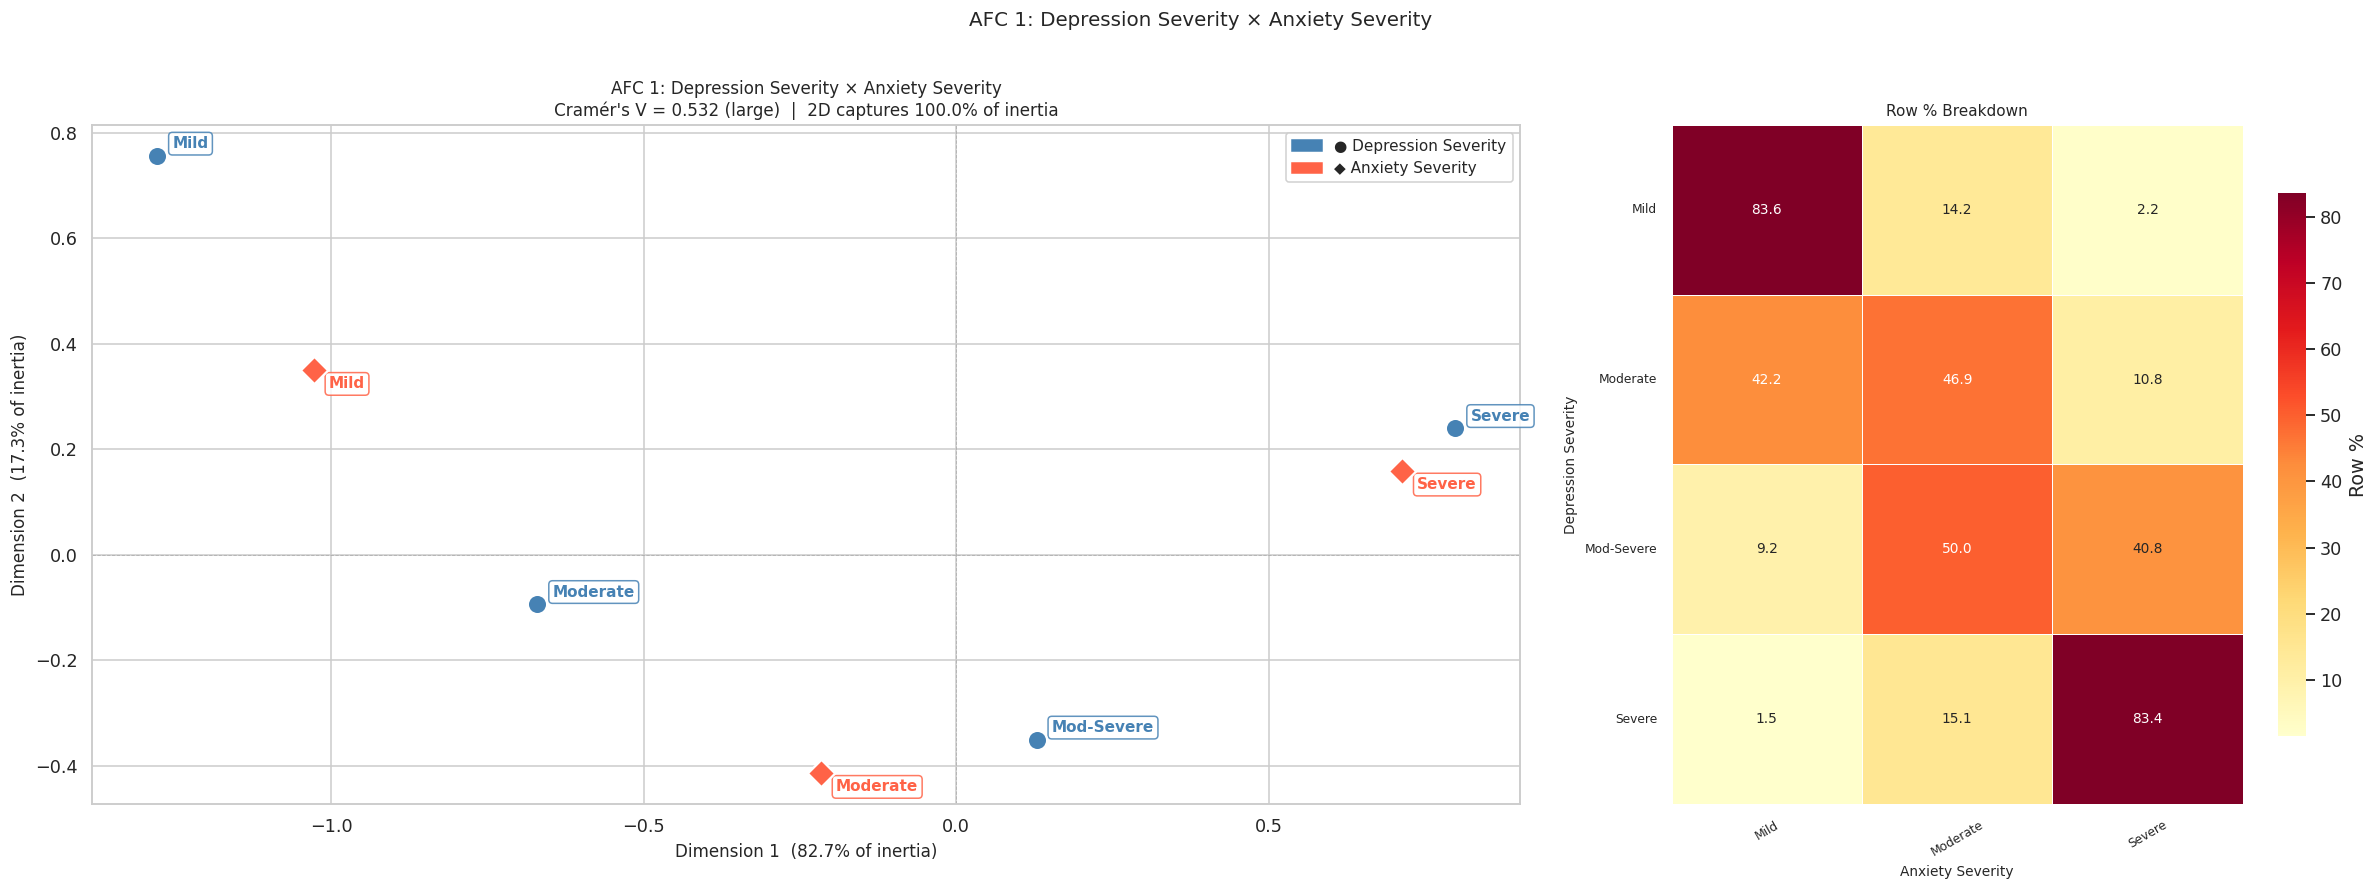

N = 171,440  |  Cramér's V = 0.5322 (large)  |  Inertia Dim1=82.7%  Dim2=17.3%  Total=100.0%


In [3]:
DEP_ORD = ['Mild','Moderate','Mod-Severe','Severe']
ANX_ORD = ['Mild','Moderate','Severe']

sub1 = df.dropna(subset=['dep_sev','anx_sev'])
ct1  = pd.crosstab(sub1['dep_sev'], sub1['anx_sev']).reindex(DEP_ORD)[ANX_ORD]

run_afc(ct1,
        title='AFC 1: Depression Severity × Anxiety Severity',
        row_label='Depression Severity',
        col_label='Anxiety Severity')


## AFC 2: Loneliness Level × Depression Severity
**V = 0.380 — Medium effect**

Does high loneliness cluster specifically with severe depression, or is the relationship more gradual?


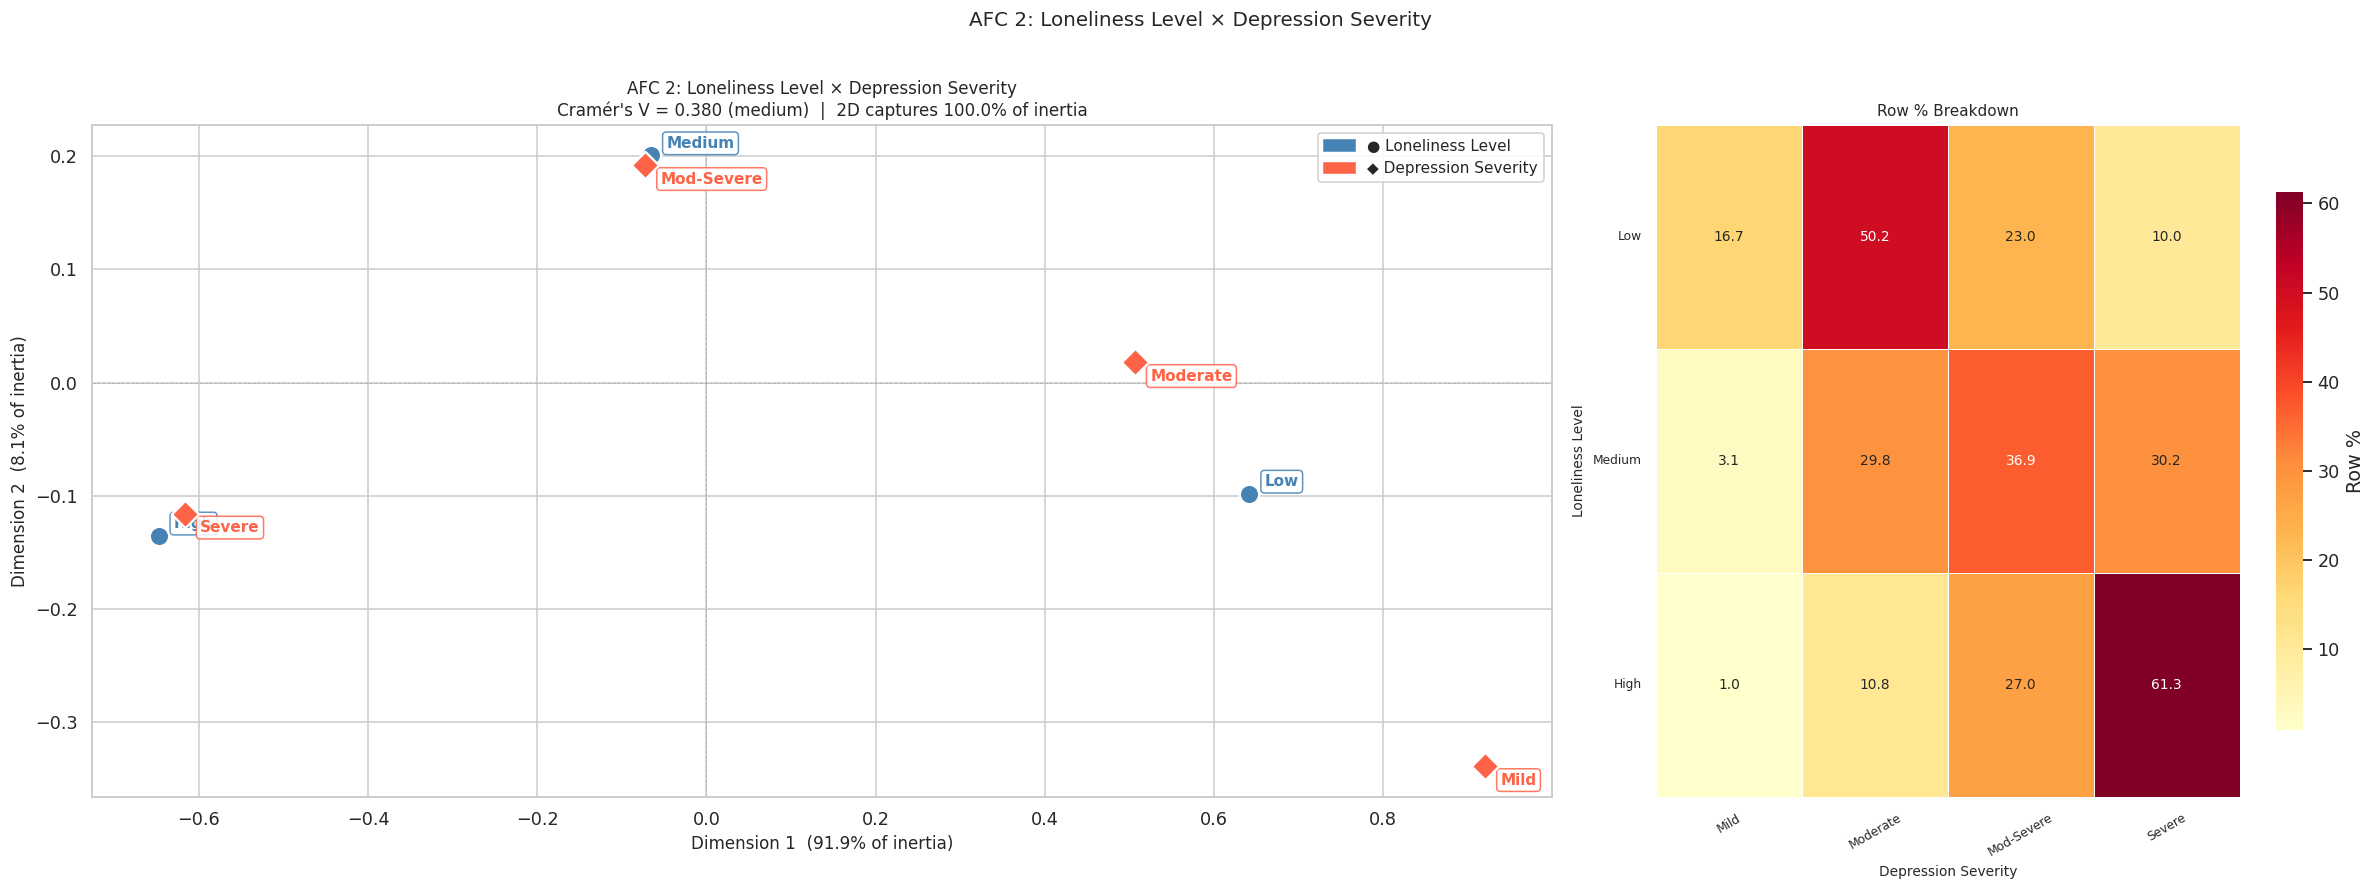

N = 170,120  |  Cramér's V = 0.3798 (medium)  |  Inertia Dim1=91.9%  Dim2=8.1%  Total=100.0%


In [4]:
LONE_ORD = ['Low','Medium','High']

sub2 = df.dropna(subset=['lonely_band','dep_sev'])
ct2  = pd.crosstab(sub2['lonely_band'], sub2['dep_sev']).reindex(LONE_ORD)[DEP_ORD]

run_afc(ct2,
        title='AFC 2: Loneliness Level × Depression Severity',
        row_label='Loneliness Level',
        col_label='Depression Severity')


## AFC 3: Self-Injury × Depression Severity
**V = 0.363 — Medium effect**

Students who self-injure — do they cluster with a specific depression severity level, or are they spread across all levels?


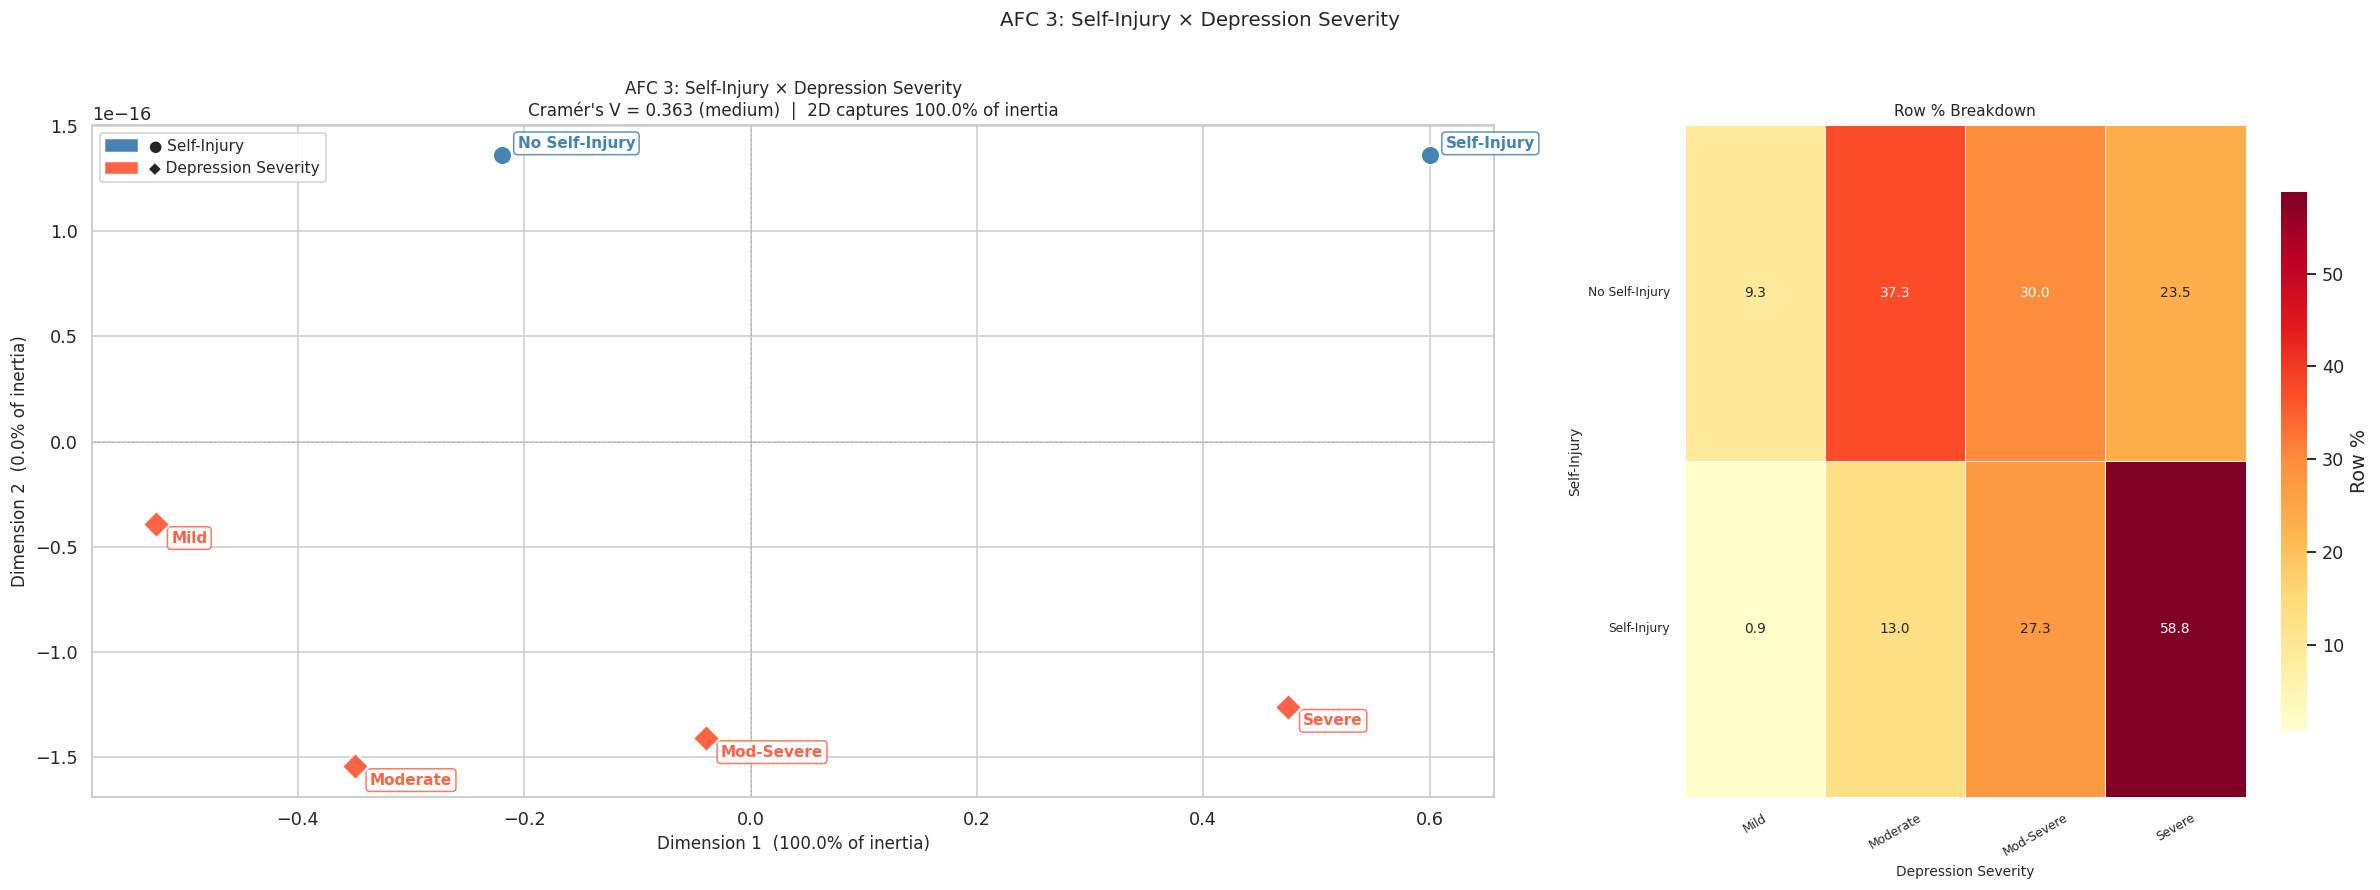

N = 164,775  |  Cramér's V = 0.3630 (medium)  |  Inertia Dim1=100.0%  Dim2=0.0%  Total=100.0%


In [5]:
sub3 = df.dropna(subset=['sib_label','dep_sev'])
ct3  = pd.crosstab(sub3['sib_label'], sub3['dep_sev'])[DEP_ORD]

run_afc(ct3,
        title='AFC 3: Self-Injury × Depression Severity',
        row_label='Self-Injury',
        col_label='Depression Severity')


## AFC 4: Flourishing Level × Depression Severity
**V = 0.349 — Medium effect**

Flourishing (Diener scale) measures positive well-being. Does low flourishing cluster with severe depression, or are they independent dimensions?


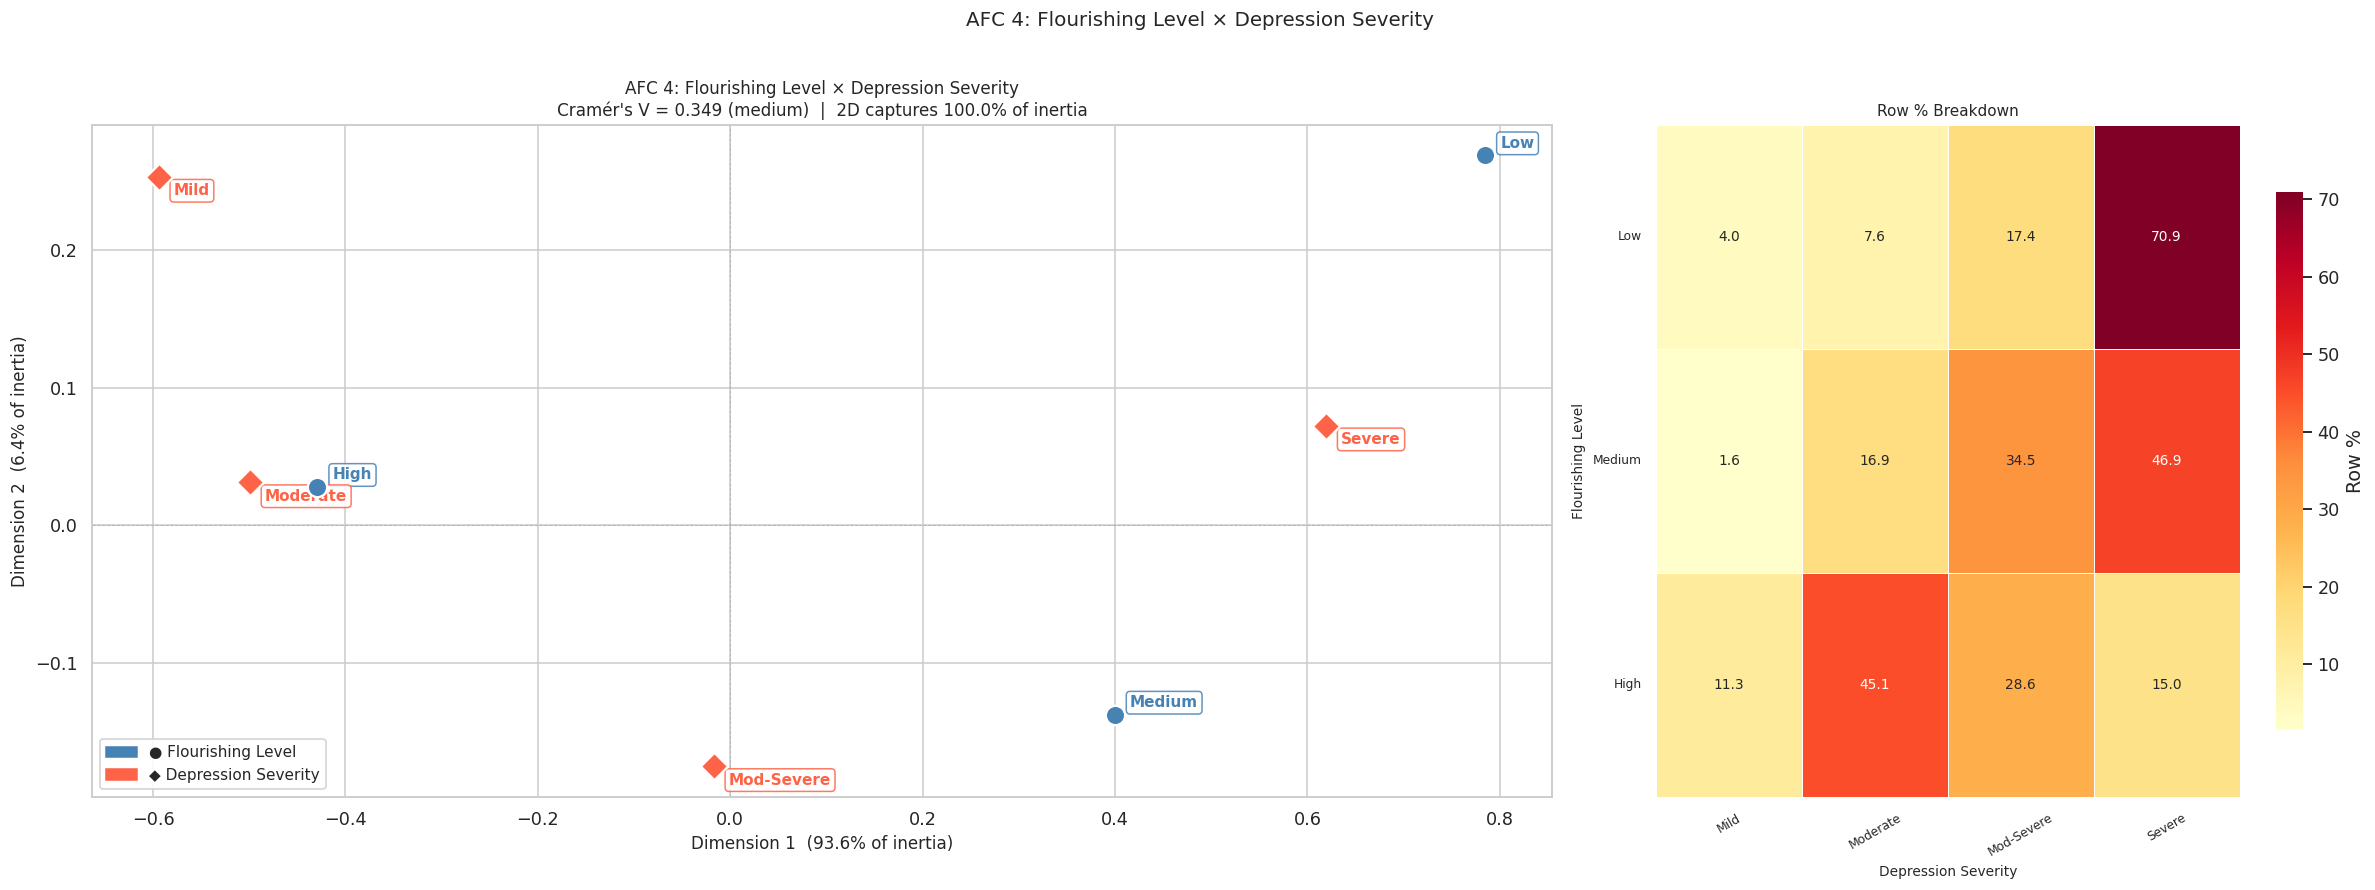

N = 172,886  |  Cramér's V = 0.3486 (medium)  |  Inertia Dim1=93.6%  Dim2=6.4%  Total=100.0%


In [6]:
FLOUR_ORD = ['Low','Medium','High']

sub4 = df.dropna(subset=['flourish_band','dep_sev'])
ct4  = pd.crosstab(sub4['flourish_band'], sub4['dep_sev']).reindex(FLOUR_ORD)[DEP_ORD]

run_afc(ct4,
        title='AFC 4: Flourishing Level × Depression Severity',
        row_label='Flourishing Level',
        col_label='Depression Severity')


## AFC 5: Flourishing Level × Loneliness Level
**V = 0.335 — Medium effect**

Two well-being dimensions — do they form a clean diagonal (high flourishing = low loneliness) or is the relationship more complex?


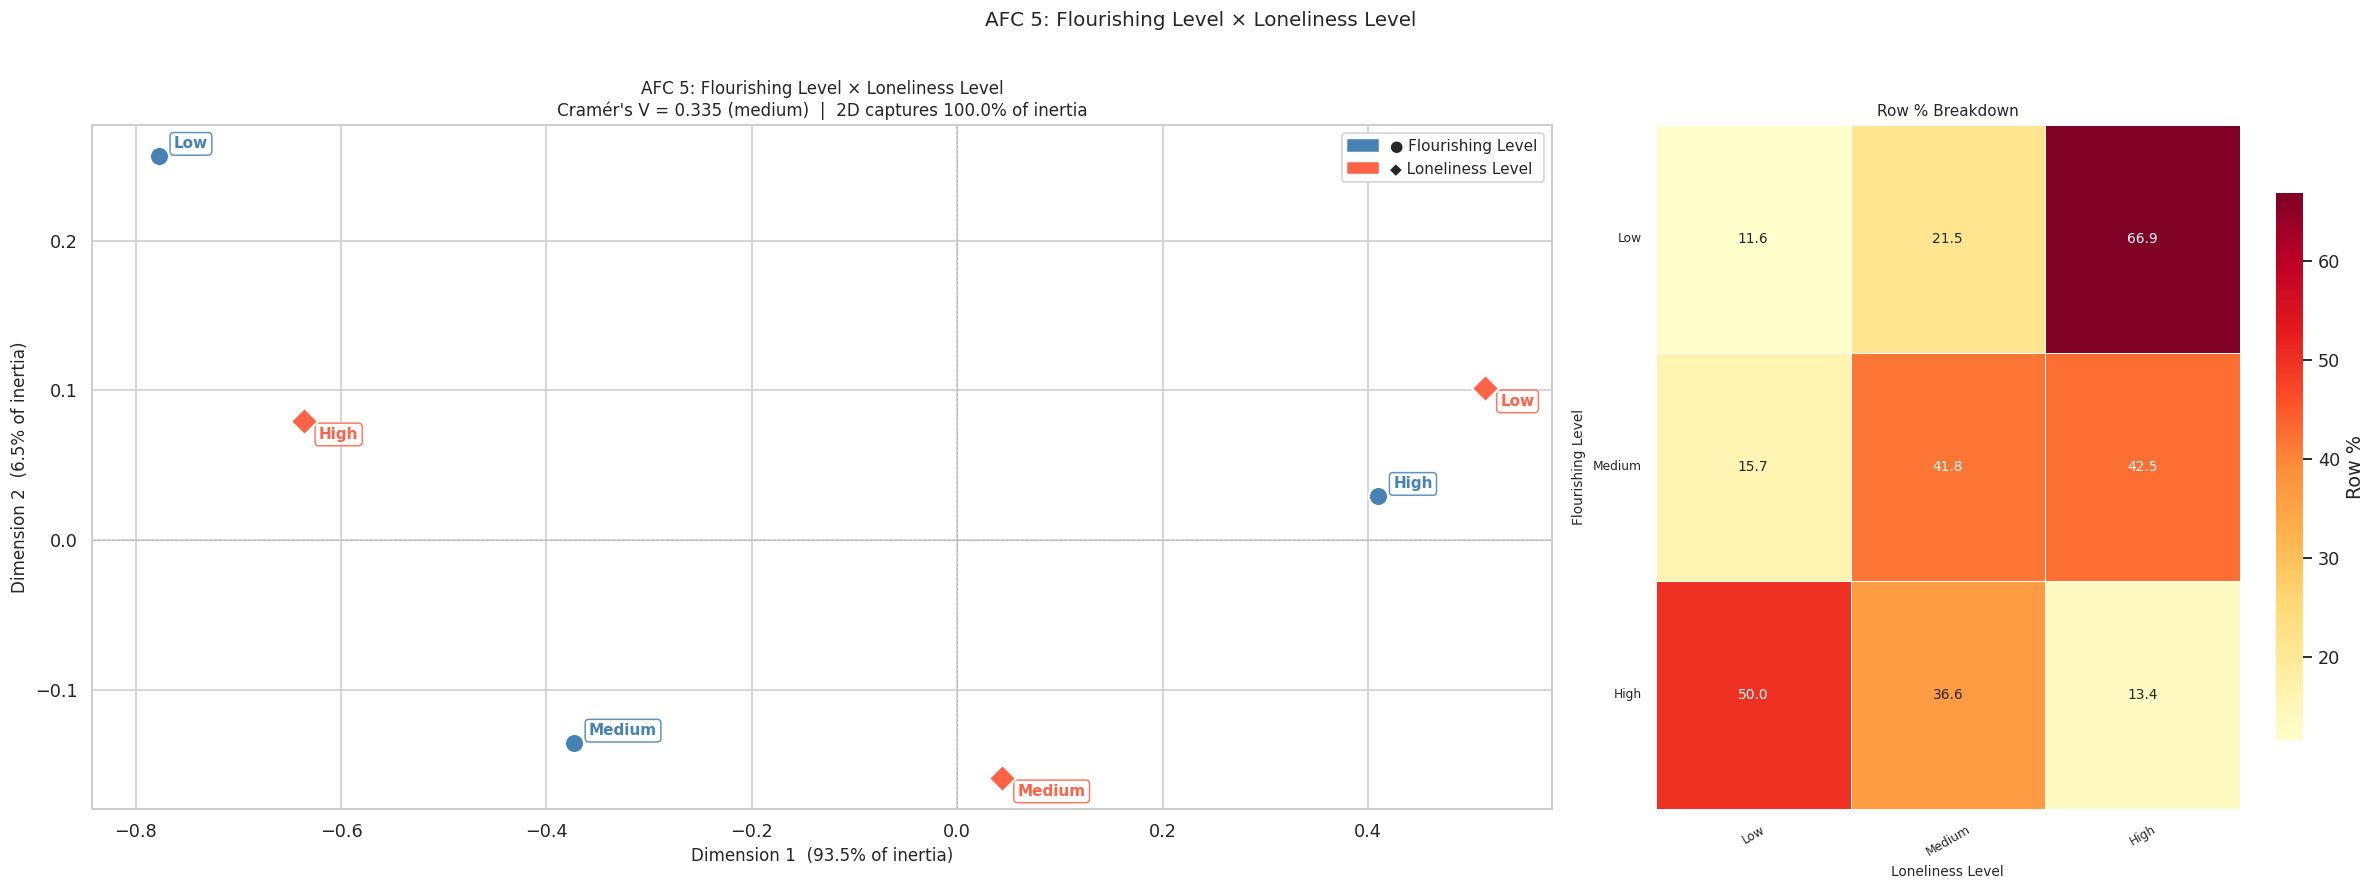

N = 170,112  |  Cramér's V = 0.3353 (medium)  |  Inertia Dim1=93.5%  Dim2=6.5%  Total=100.0%


In [7]:
sub5 = df.dropna(subset=['flourish_band','lonely_band'])
ct5  = pd.crosstab(sub5['flourish_band'], sub5['lonely_band']).reindex(FLOUR_ORD)[LONE_ORD]

run_afc(ct5,
        title='AFC 5: Flourishing Level × Loneliness Level',
        row_label='Flourishing Level',
        col_label='Loneliness Level')


## AFC 6: Unmet Need × Depression Severity
**V = 0.259 — Small-Medium effect**

Among students who perceive a need for mental health help, who gets treatment and who doesn't? Does unmet need cluster with more severe depression?


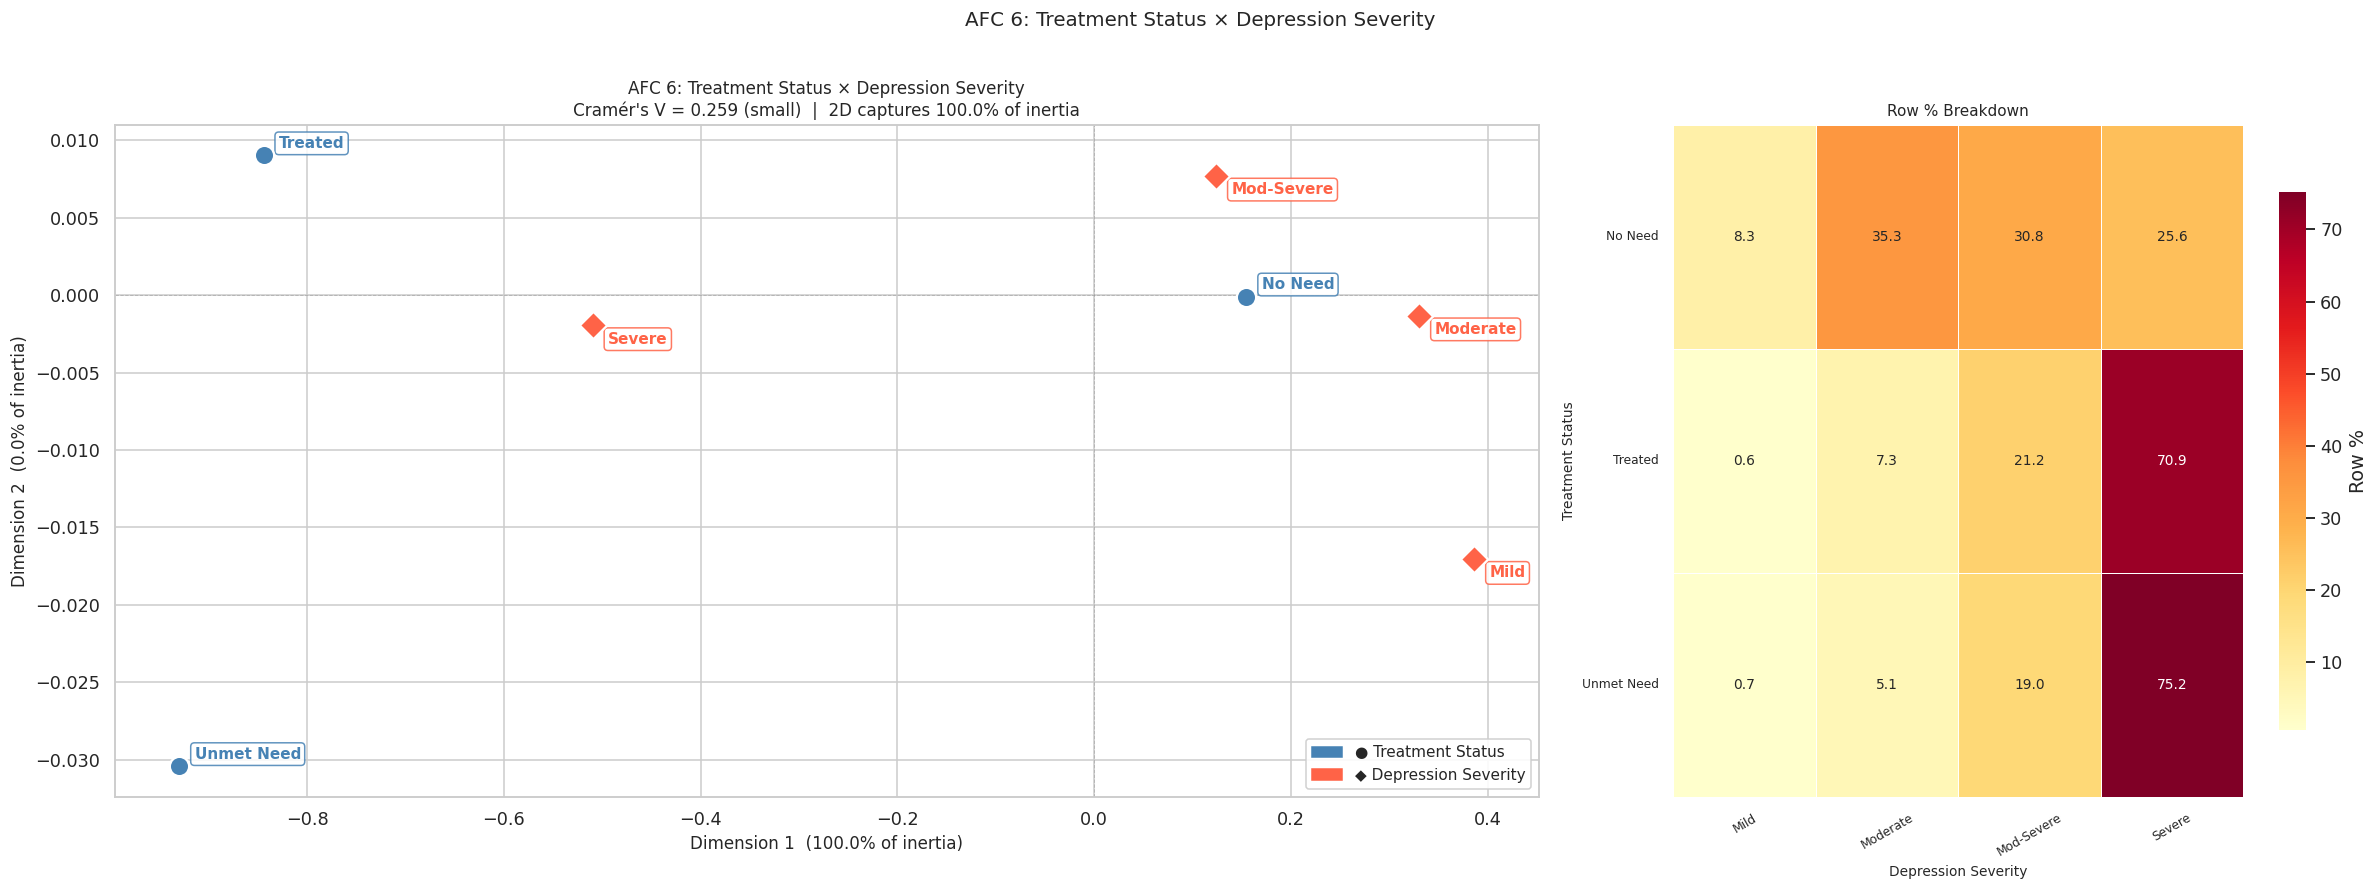

N = 173,088  |  Cramér's V = 0.2585 (small)  |  Inertia Dim1=100.0%  Dim2=0.0%  Total=100.0%


In [8]:
NEED_ORD = ['No Need','Treated','Unmet Need']

sub6 = df.dropna(subset=['unmet_need','dep_sev'])
ct6  = pd.crosstab(sub6['unmet_need'], sub6['dep_sev']).reindex(NEED_ORD)[DEP_ORD]

run_afc(ct6,
        title='AFC 6: Treatment Status × Depression Severity',
        row_label='Treatment Status',
        col_label='Depression Severity')


## Summary: AFC Results

Analysis                       Description       N  Cramér's V Effect
    AFC1     Depression × Anxiety Severity 171,440      0.5322  large
    AFC2  Loneliness × Depression Severity 170,120      0.3798 medium
    AFC3 Self-Injury × Depression Severity 164,775      0.3630 medium
    AFC4 Flourishing × Depression Severity 172,886      0.3486 medium
    AFC5          Flourishing × Loneliness 170,112      0.3353 medium
    AFC6  Unmet Need × Depression Severity 173,088      0.2585  small


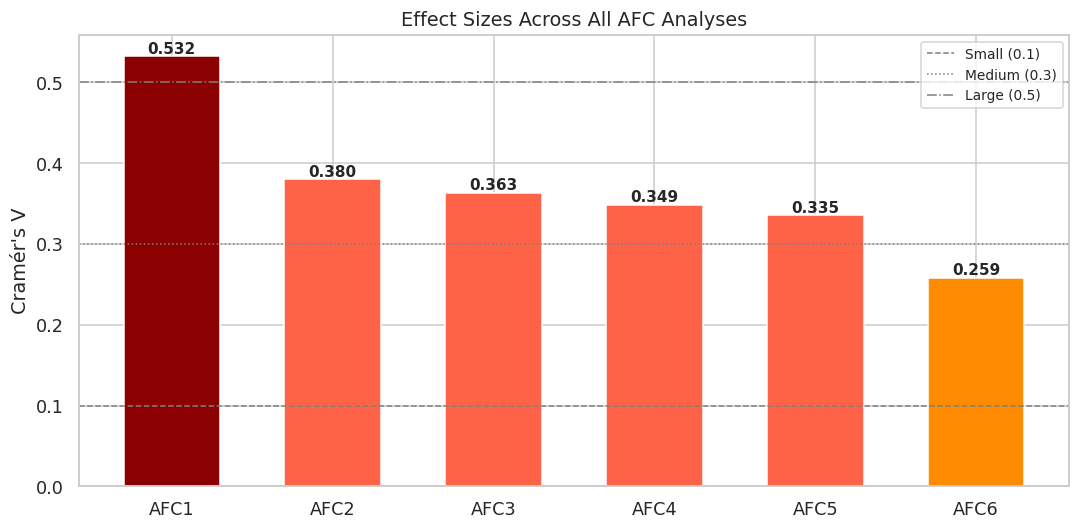

In [9]:
analyses = [
    ('AFC1', 'Depression × Anxiety Severity',    ct1),
    ('AFC2', 'Loneliness × Depression Severity', ct2),
    ('AFC3', 'Self-Injury × Depression Severity',ct3),
    ('AFC4', 'Flourishing × Depression Severity',ct4),
    ('AFC5', 'Flourishing × Loneliness',         ct5),
    ('AFC6', 'Unmet Need × Depression Severity', ct6),
]

rows = []
for name, desc, ct in analyses:
    obs = ct.values.astype(float)
    N   = obs.sum()
    exp = obs.sum(axis=1,keepdims=True)*obs.sum(axis=0,keepdims=True)/N
    chi2 = ((obs-exp)**2/exp).sum()
    min_dim = min(ct.shape[0]-1, ct.shape[1]-1)
    v = np.sqrt(chi2/(N*min_dim))
    eff = 'large' if v>=0.5 else ('medium' if v>=0.3 else ('small' if v>=0.1 else 'negligible'))
    rows.append({'Analysis':name,'Description':desc,
                 'N':f'{int(N):,}',"Cramér's V":round(v,4),'Effect':eff})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
vs = [r["Cramér's V"] for r in rows]
colors = ['darkred' if v>=0.5 else ('tomato' if v>=0.3 else ('darkorange' if v>=0.1 else 'steelblue'))
          for v in vs]
bars = ax.bar([r['Analysis'] for r in rows], vs, color=colors, edgecolor='white', width=0.6)
ax.axhline(0.1, color='gray', ls='--', lw=1, label='Small (0.1)')
ax.axhline(0.3, color='gray', ls=':',  lw=1, label='Medium (0.3)')
ax.axhline(0.5, color='gray', ls='-.', lw=1, label='Large (0.5)')
ax.set_ylabel("Cramér's V")
ax.set_title("Effect Sizes Across All AFC Analyses")
ax.legend(fontsize=9)
for bar, v in zip(bars, vs):
    ax.annotate(f'{v:.3f}', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()
